In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import os

IMG_SIZE = 128
BATCH_SIZE = 8

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_data = datagen.flow_from_directory(
    "dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",   # IMPORTANT
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_data, epochs=10)

os.makedirs("model", exist_ok=True)
model.save("model/language_model.h5")

print("Model Saved Successfully ✅")

Found 26 images belonging to 3 classes.
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 239ms/step - accuracy: 0.1923 - loss: 1.8028
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.4615 - loss: 1.3054
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.6154 - loss: 0.8481
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.7308 - loss: 0.6938
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.8462 - loss: 0.5342
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.8846 - loss: 0.4233
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.8077 - loss: 0.3603
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.8462 - loss: 0.3270
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.9231 - loss: 0.2641
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - accuracy: 0.9231 - loss: 0.2355


Model Saved Successfully ✅


In [8]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

model = load_model("model/language_model.h5")

# Hardcode class names temporarily (avoid generator confusion)
class_names = ["english", "tamil", "telugu"]

def predict_language(image):

    # Ensure 3 channel image
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    img = cv2.resize(image, (128,128))
    img = img.astype("float32") / 255.0

    print("Shape before expand:", img.shape)

    img = np.expand_dims(img, axis=0)

    print("Final shape:", img.shape)

    prediction = model.predict(img)
    index = np.argmax(prediction)
    confidence = float(np.max(prediction))

    return class_names[index], confidence

Found 28 images belonging to 3 classes.
Found 5 images belonging to 3 classes.
Detected Classes: {'english': 0, 'tamil': 1, 'telugu': 2}
Number of Classes: 3
Training Images: 28
Validation Images: 5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,340,163 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1786 - loss: 1.9924 - val_accuracy: 0.2000 - val_loss: 1.0532
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.6429 - loss: 0.8880 - val_accuracy: 0.2000 - val_loss: 1.3854
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step - accuracy: 0.6786 - loss: 0.7026 - val_accuracy: 0.2000 - val_loss: 1.3169
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 461ms/step - accuracy: 0.8214 - loss: 0.5718 - val_accuracy: 0.4000 - val_loss: 1.4217
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 396ms/step - accuracy: 0.8571 - loss: 0.4588 - val_accuracy: 0.2000 - val_loss: 1.8937
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 429ms/step - accuracy: 0.8214 - loss: 0.3943 - val_accuracy: 0.2000 - val_loss: 1.5345
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step - accuracy: 0.9286 - loss: 0.3077 - val_accuracy: 0.2000 - val_loss: 1.9559
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 432ms/step - accuracy: 0.9286 - loss: 0.2542 - val_accuracy: 0.4000 - val_loss: 1


🔥 Final Validation Accuracy: 20.0 %
Model Saved Successfully ✅


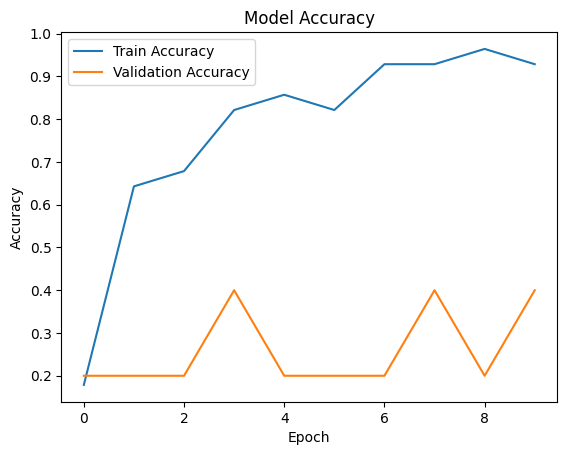

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import os

IMG_SIZE = 128
BATCH_SIZE = 8
EPOCHS = 10

# Data Augmentation + Validation Split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_data = datagen.flow_from_directory(
    "dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

print("Detected Classes:", train_data.class_indices)
print("Number of Classes:", train_data.num_classes)
print("Training Images:", train_data.samples)
print("Validation Images:", val_data.samples)

# Transfer Learning Model
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

# Evaluate Model
loss, acc = model.evaluate(val_data)
print("\n🔥 Final Validation Accuracy:", round(acc * 100, 2), "%")

# Save Model
os.makedirs("model", exist_ok=True)
model.save("model/language_model.h5")
print("Model Saved Successfully ✅")

# Plot Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()